<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"></center> </p>

<hr style="border-width:2px;border-color:#ff6745">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Analyse exploratoire détaillée </h2></center>
<hr style="border-width:2px;border-color:#ff6745">

# I - Récupération des données précédentes

Nous commencons par importer les librairies nécessaires pour manipuler nos données :


In [2]:
# Gestion des chemins
from pathlib import Path

# Jeux de données
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Statistiques
import statsmodels.api as sm
from statsmodels.regression.linear_model import RegressionResults
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Préprocessing
from sklearn.preprocessing import StandardScaler


Puis on récupère les données collectées aux étapes précédentes :

In [3]:
# Répertoire des données d'entrée
input_path = Path("../../data/local_data/input/")

# Répertoire des données résultats intermédiaires
temp_path = Path("../../data/local_data/temp/")

# Répertoire des données de sortie
output_path = Path("../../data/local_data/output/")

# Chemin du dataset de production
input_datasets = temp_path / 'temp_region_2020_2025.csv'


On charge le jeu de données **region_2020_2025.csv** contenant l'ensemble des données précédemment collectées :
- les données de production issues d'**éCO2mix** ;
- les données astronomiques calculées concernant la position du soleil avec **PySolar** ;
- les données athmosphériques issues de **CAMS** (Copernicus Atmosphere Monitoring Service) ; et
- les données météorologiques issues de **NASA POWER**.  

Les données que nous avions collectées au niveau des cinq points d'intérêt ont été préalablement aggrégées car elles présentaient trop de corrélation entre elles.


In [4]:
# On récupère le dataset raw_2020_2025.csv
df = pd.read_csv(
    input_datasets, 
    index_col='datetime_utc', 
    parse_dates=True)


On se donne une date de fin de période pour l'entrainement :

In [5]:
end_train = '2023-12-31'

# II - Exploration préliminaire

Nous allons maintenant réaliser une première exploration de notre jeu de données afin de :
- visualiser les premières lignes du jeu de données,
- examiner les types de variables et les valeurs manquantes.


In [6]:
# Affichage du début et de la fin du jeu de données
display(df)


,consommation,region_altitude,region_azimuth,region_bhi,region_bni,region_clear_sky_bhi,region_clear_sky_bni,region_clear_sky_dhi,region_clear_sky_ghi,region_dhi,...,region_nebulosite,region_reliability,region_temperature,region_toa,region_vitesse_vent,signed_var_tch_tp30,solaire,target,tch_solaire,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,-67.658747,334.860133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.86520,1.0,3.23070,0.0,1.34110,0.0,0.0,0.0,0.0,0.0
2019-12-31 23:30:00+00:00,5907.0,-69.154695,353.234530,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,24.55650,1.0,3.38585,0.0,1.36150,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:00:00+00:00,5724.0,-68.877374,12.560776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,25.24780,1.0,3.54100,0.0,1.38190,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:30:00+00:00,5749.0,-66.891776,30.183447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.23310,1.0,3.60800,0.0,1.33655,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:00:00+00:00,5700.0,-63.589084,44.705668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.21840,1.0,3.67500,0.0,1.29120,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,-56.223103,297.107647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,36.40500,1.0,1.24320,0.0,3.31620,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,-60.811889,306.996098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,37.02250,1.0,1.09590,0.0,3.27060,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,-64.763196,319.404019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,36.08765,1.0,0.96695,0.0,3.15875,0.0,0.0,0.0,0.0,0.0


Le jeu de données comprend 105 170 lignes et 21 colonnes. Les données sont collectées avec une résolution temporelle de **30 minutes** entre la dernière heure UTC du 31 décembre 2019 (`1er janvier 2020` heure française) et le `30 décembre 2025` (date de fin de service du satellite ayant collecté les données de nébulosité).

In [7]:
# Informations générales sur la structure des données
df.info()

print("\nNombre de valeur manquante :", df.isna().sum().sum())
print("Nombre de doublons :", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105170 entries, 2019-12-31 23:00:00+00:00 to 2025-12-30 23:30:00+00:00
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   consommation          105170 non-null  float64
 1   region_altitude       105170 non-null  float64
 2   region_azimuth        105170 non-null  float64
 3   region_bhi            105170 non-null  float64
 4   region_bni            105170 non-null  float64
 5   region_clear_sky_bhi  105170 non-null  float64
 6   region_clear_sky_bni  105170 non-null  float64
 7   region_clear_sky_dhi  105170 non-null  float64
 8   region_clear_sky_ghi  105170 non-null  float64
 9   region_dhi            105170 non-null  float64
 10  region_ghi            105170 non-null  float64
 11  region_humidite       105170 non-null  float64
 12  region_nebulosite     105170 non-null  float64
 13  region_reliability    105170 non-null  float64
 14  region

Il n'y a **aucune valeur manquante** et toutes les données sont **numériques**, à l'exception de l'index au format `DatetimeIndex`.

- **`consommation`** : consommation électrique totale du périmètre considéré sur l'intervalle de temps donné.
- **`datetime_utc`** : horodatage en temps universel coordonné (UTC) correspondant à l'instant d'agrégation des données (résolution 30 minutes).
- **`signed_var_tch_tp30`** : variabilité signée du taux de charge de la production solaire à t + 30 minutes.
- **`solaire`** : production électrique issue des installations photovoltaïques sur le périmètre considéré.
- **`target`** : variabilité absolue du taux de charge de la production solaire à t + 30 minutes (notre variable cible).
- **`tco_solaire`** : taux de couverture de la production solaire.
- **`tch_solaire`** : taux de charge de la production solaire.
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit). 
- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).    
- **`bhi`** *(Beam Horizontal Irradiance)* : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).
- **`bni`** *(Beam Normal Irradiance)* : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²). 
- **`clear_sky_bhi`** : composante directe horizontale en conditions de ciel clair (Wh/m²).   
- **`clear_sky_bni`** : irradiance directe normale en conditions de ciel clair (Wh/m²).
- **`clear_sky_dhi`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²). 
- **`clear_sky_ghi`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²). 
- **`dhi`** *(Diffuse Horizontal Irradiance)* : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).     
- **`ghi`** *(Global Horizontal Irradiance)* : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².   
- **`humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).
- **`nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).   
- **`reliability`** : fiabilité des données CAMS (bhi, bni, clear_sky_bhi, clear_sky_bni, clear_sky_dhi, clear_sky_ghi, dhi, ghi, toa).
- **`temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).    
- **`toa`** *(Top Of Atmosphere)* : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.
- **`vitesse_vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  

In [8]:
# Informations statistiques générales
display(df.describe())


,consommation,region_altitude,region_azimuth,region_bhi,region_bni,region_clear_sky_bhi,region_clear_sky_bni,region_clear_sky_dhi,region_clear_sky_ghi,region_dhi,...,region_nebulosite,region_reliability,region_temperature,region_toa,region_vitesse_vent,signed_var_tch_tp30,solaire,target,tch_solaire,tco_solaire
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,...,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,1.051700e+05,105170.000000,105170.000000,105170.000000,105170.000000
mean,4472.479405,0.342442,180.261128,63.695099,117.963388,89.202855,166.233043,23.809474,113.012329,30.095945,...,51.102065,0.978336,14.401564,156.257087,2.687622,-8.445169e-19,319.292536,2.393873,16.578480,7.081328
std,839.410834,34.209839,101.041300,104.646571,159.731755,124.410592,187.241797,30.327126,150.410731,42.190804,...,34.211995,0.083532,8.475625,197.665300,1.511006,4.036436e+00,466.429135,3.249944,23.562155,10.398950
min,2620.000000,-69.612807,1.065672,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.054200,0.500000,-4.733200,0.000000,0.164400,-1.685000e+01,0.000000,0.000000,0.000000,0.000000
25%,3851.000000,-25.754906,90.421958,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.299587,1.000000,7.657550,0.000000,1.457812,-4.400000e-01,0.000000,0.000000,0.000000,0.000000
50%,4373.000000,0.580092,179.780724,0.041539,0.372436,0.390284,9.140822,1.951463,2.464659,1.620662,...,47.118500,1.000000,13.474800,8.362237,2.420550,0.000000e+00,4.000000,0.310000,0.220000,0.090000
75%,5033.000000,26.441409,270.698881,96.273762,247.707725,168.130962,371.921211,44.130255,215.830080,50.597442,...,86.663000,1.000000,20.368500,304.146134,3.568800,1.900000e-01,585.000000,4.290000,31.740000,12.810000
max,8044.000000,69.562549,358.763443,463.812108,509.467994,463.812108,510.283201,221.661441,504.713572,258.522808,...,100.000000,1.000000,39.457900,617.546796,10.552600,2.497000e+01,2108.000000,24.970000,91.350000,51.490000


# III - Exploration des variables explicatives

## A - Variables explicatives collectées au niveau régional


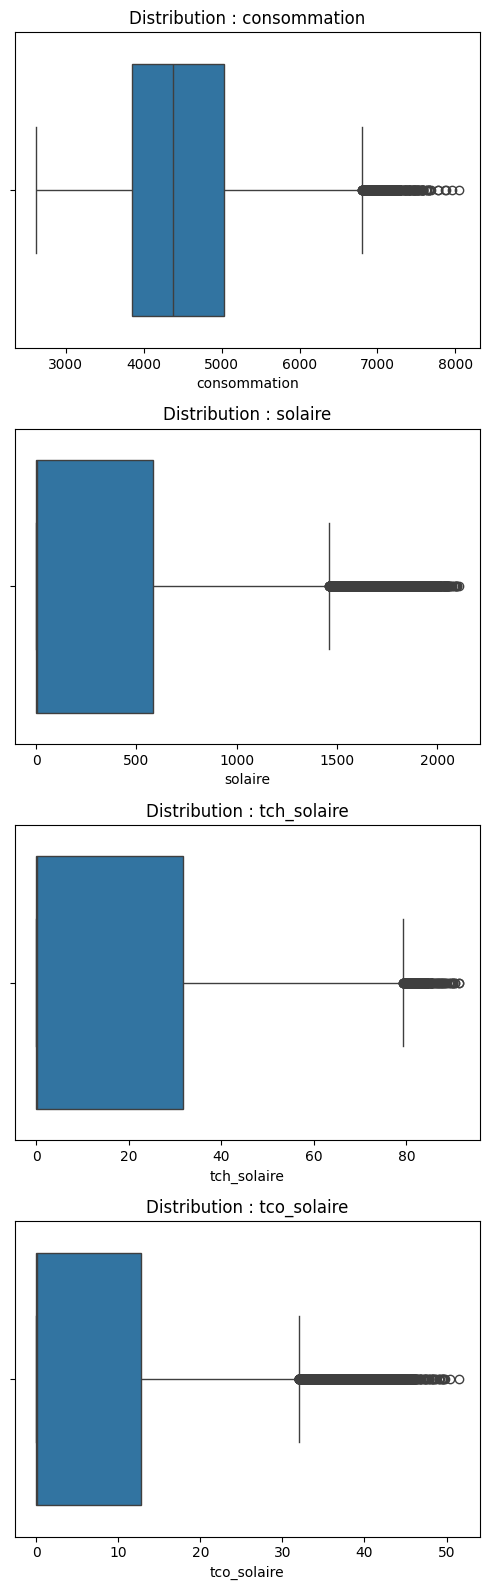

In [14]:
# Sélection des variables régionales à analyser
cols = [v for v in df.columns if (v[:7]!='region_' and v!='target' and v!='signed_var_tch_tp30')]

fig, axes = plt.subplots(len(cols), 1, figsize=(5, 4 * len(cols)))

for ax, col in zip(axes, cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution : {col}")

plt.tight_layout()
plt.show()


## B - Variables explicatives collectées au niveau communal

Afin d’explorer la distribution des variables météorologiques régionales construites par agrégation pondérée, une analyse exploratoire est réalisée à l’aide de boxplots.

L’analyse est restreinte aux instants où l’irradiation globale régionale (GHI_region) est significative (supérieure à 5), afin d’exclure les périodes nocturnes ou non pertinentes d’un point de vue énergétique.


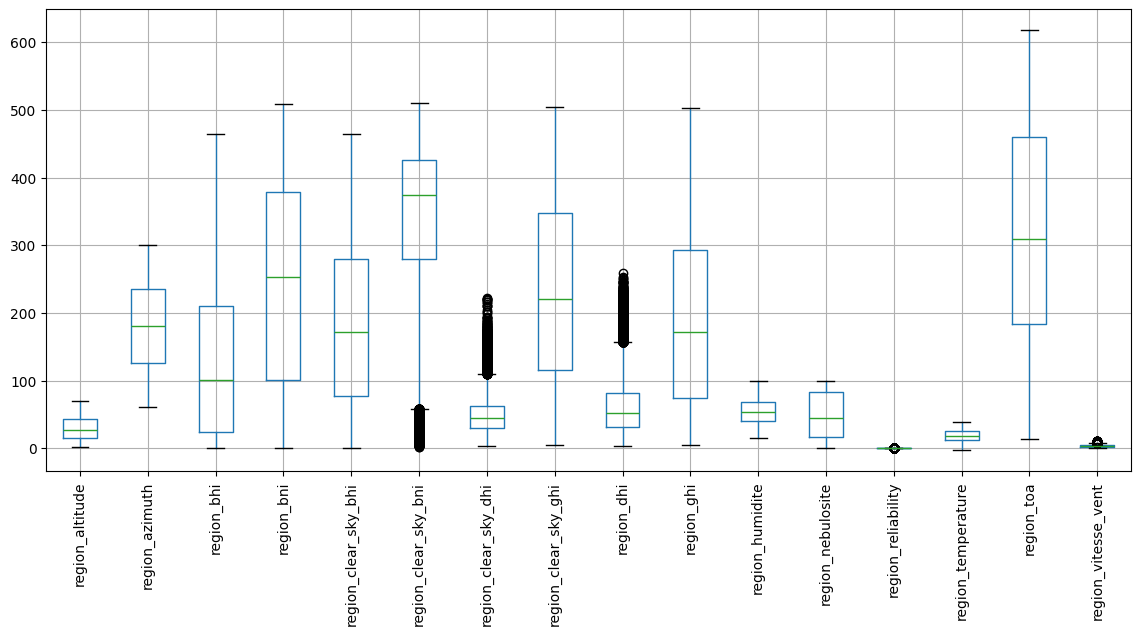

In [9]:
# Sélection des variables régionales à analyser
region_vars = [v for v in df.columns if (v[:7]=='region_')]

# Filtrage des observations :
# on conserve uniquement les pas de temps où l'irradiation globale
# régionale est significative (GHI_region > 5)
df_filtered = df.loc[df["region_ghi"] > 5, region_vars]

# Visualisation exploratoire des distributions
# à l'aide de boxplots pour comparer les variables régionales
df_filtered.boxplot(rot=90, figsize=(14, 6));


Les distributions de ces variables sont diverses. Les échelles de valeurs diffèrent parfois de deux ordres de grandeurs : une normalisation des données sera nécessaire pour certains algorithmes de modélisation.

Les variables region_clear_sky_bhi, region_clear_sky_dhi et region_dhi présentent des valeurs extrêmes, mais celles ci ne paraissent pas abérrantes.

On vérifie si certaines variables ont une très faible variance :

In [10]:
df_train = df[:end_train]

# Trouver les variables explicatives qui ont une variance inférieure à 0.01
sel = VarianceThreshold(threshold=0.01)
sel.fit(df_train)

# Afficher les variables concernées
mask = sel.get_support()
print("Variables de faible variance :", df_train.columns[~mask])


Variables de faible variance : Index(['region_reliability'], dtype='object')


La variable `reliability` concerne la fiabilité des mesures du jeu de données CAMS (bhi, bni, clear_sky_bhi, clear_sky_bni, clear_sky_dhi, clear_sky_ghi, dhi, ghi, toa). En pratique cette variable présente une très faible variabilité et semble peu exploitable.

# IV - Analyse de la variable cible

## A - Définition de TCH
Le **TCH (Taux de Charge ou Facteur de Charge)** mesure l'utilisation réelle d'une capacité de production électrique par rapport à ce qu'elle pourrait produire à plein régime.  
Il se calcule ainsi :

$$
\text{TCH} = \frac{\text{Production réelle}}{\text{Capacité installée}}
$$

## B - Variable cible

Nous avons défini la `valeur absolue de la variabilité à t+1`, notre variable cible, telle que :

$$
\left|V(t+\Delta t)\right| = \Big|\Delta TCH(t+\Delta t)\Big|
$$



## C - Méthodes utilisées

### 1 - **Statistiques horaires** : 

In [11]:
# df_day = df[df["hour"].between(4,19)]
df_day = df.loc[df.region_ghi > 0]
df_day['hour'] = df_day.index.hour

# Calculer les statistiques horaires pour la production solaire
hour_stats = df_day.groupby('hour')[['tch_solaire', 'target']].describe() 

display(hour_stats)


/tmp/ipykernel_9900/1897576574.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['hour'] = df_day.index.hour


tch_solaire                                                               \
           count       mean        std   min      25%     50%      75%    max   
hour                                                                            
4         1103.0   0.232529   0.356519  0.00   0.0000   0.000   0.4000   1.98   
5         2201.0   2.409060   2.409581  0.00   0.2200   1.740   3.8000   9.58   
6         3203.0   8.382869   7.358798  0.00   1.2300   7.170  13.8650  27.17   
7         4382.0  16.599651  14.188487  0.00   2.0900  14.510  29.1200  49.16   
8         4382.0  30.277707  18.163218  0.22  12.8925  31.500  46.5175  66.62   
9         4382.0  42.572827  19.389726  0.82  26.8125  45.690  59.5700  80.85   
10        4382.0  50.569247  19.665360  1.64  37.3225  54.060  67.2100  88.38   
11        4382.0  53.841570  19.546221  2.56  41.7725  57.345  70.2300  91.35   
12        4382.0  53.103656  19.368453  2.25  41.1200  56.350  69.4075  91.30   
13        4382.0  48.870963  19.058319  2.41  36.2925  51.395  65.0075  88.48   
14        4382.0  40.802024  18.488413  1.31  25.8075  42.690  56.9850  81.46   
15        4382.0  29.175831  17.382541  0.13  12.9525  29.385  44.7400  68.25   
16        4015.0  18.009851  13.712290  0.00   4.4050  17.000  30.0050  49.51   
17        2881.0  10.008747   7.559500  0.00   3.0600   9.250  15.3600  30.69   
18        1914.0   3.337696   2.716416  0.00   0.9800   2.830   4.9775  11.16   
19         762.0   0.567283   0.557116  0.00   0.0700   0.405   0.9200   2.75   

      target                                                         
       count      mean       std  min     25%    50%     75%    max  
hour                                                                 
4     1103.0  1.208404  0.822044  0.0  0.5100  1.000  1.9200   3.54  
5     2201.0  3.513262  2.021400  0.0  1.8700  3.490  4.9400   8.38  
6     3203.0  6.313940  3.311746  0.0  3.3700  7.120  9.0900  12.80  
7     4382.0  6.718158  3.513213  0.0  3.6300  7.690  9.6200  14.45  
8     4382.0  6.639026  2.795183  0.0  4.9825  6.945  8.5900  14.45  
9     4382.0  4.825623  2.422657  0.0  3.2500  4.720  6.3400  18.17  
10    4382.0  2.793266  1.917103  0.0  1.4425  2.490  3.7300  24.97  
11    4382.0  1.668517  1.837484  0.0  0.4700  1.075  2.1800  15.03  
12    4382.0  2.224806  1.898769  0.0  0.9200  1.750  2.9800  18.64  
13    4382.0  3.862230  2.210278  0.0  2.3100  3.620  5.2100  20.17  
14    4382.0  5.690397  2.698829  0.0  3.8000  5.720  7.6275  16.85  
15    4382.0  6.588706  2.905117  0.0  4.4125  6.895  8.7900  15.04  
16    4015.0  5.969756  3.614330  0.0  2.5400  6.530  9.1600  14.64  
17    2881.0  4.861517  2.952146  0.0  2.3700  5.020  7.3300  11.47  
18    1914.0  2.211651  1.472942  0.0  0.9350  2.180  3.2000   6.23  
19     762.0  0.527913  0.504695  0.0  0.0700  0.380  0.8800   2.27

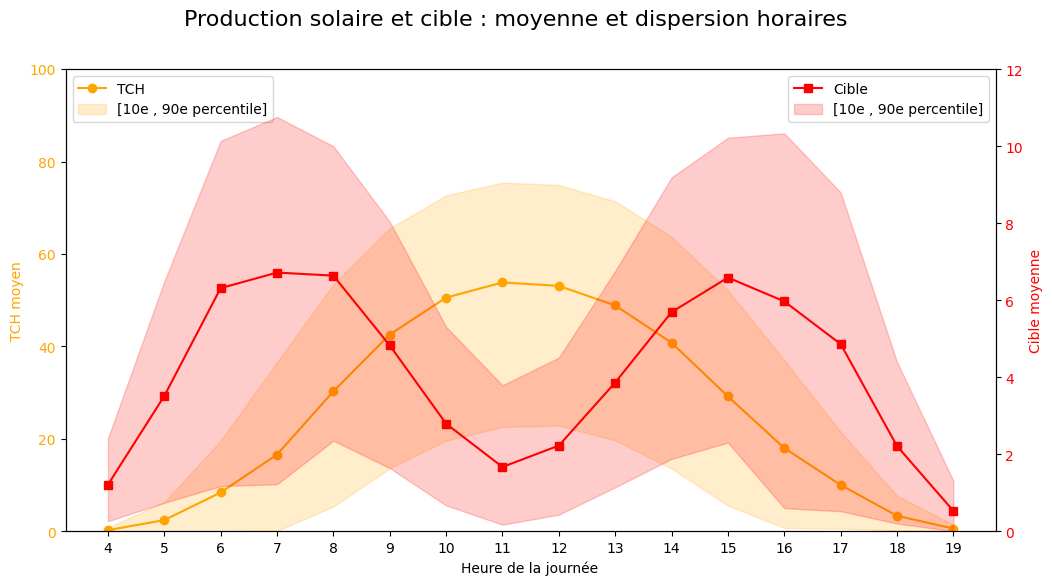

In [12]:
heures = hour_stats.index
mean_tch = hour_stats['tch_solaire']['mean']
mean_target = hour_stats['target']['mean']

# Calcul des percentiles
p10_tch = hour_stats['p10'] = df_day.groupby('hour')['tch_solaire'].quantile(0.10)
p90_tch = hour_stats['p90'] = df_day.groupby('hour')['tch_solaire'].quantile(0.90)
p10_target = hour_stats['p10'] = df_day.groupby('hour')['target'].quantile(0.10)
p90_target = hour_stats['p90'] = df_day.groupby('hour')['target'].quantile(0.90)

# Figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande
ax1.plot(heures, mean_tch, marker='o', color='orange', label='TCH')
ax1.fill_between(heures, p10_tch, p90_tch, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Heure de la journée ')
ax1.set_ylabel('TCH moyen', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_ylim(0, 100)
ax1.set_xticks(heures)

# Cible sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(heures, mean_target, marker='s', color='red', label='Cible')
ax2.fill_between(heures, p10_target, p90_target, color='red', alpha=0.2, label='[10e , 90e percentile]')
ax2.set_ylabel('Cible moyenne', color='red')
ax2.set_ylim(0, 12)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire et cible : moyenne et dispersion horaires', fontsize=16)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque heure de la journée :  
- la **moyenne de la production solaire** (`mean`) en orange ;  
- la **zone orange claire** représentant la **dispersion absolue** autour de la moyenne (écart-type) de la production solaire ;  
- la **variable cible** (courbe rouge sur l'axe secondaire);
- la **zone rouge claire** représentant la **dispersion absolue** autour de la moyenne (écart-type) de la variable cible ;  


**Observations**

1. **Production solaire**
    - La bande est **très étroite tôt le matin (4–5h) et en soirée (18–19h)** : la production est faible et la dispersion absolue reste limitée.
    - Elle devient **très large entre 6h et 12h**, lorsque la production solaire augmente fortement et varie davantage d'un jour à l'autre.
    - L'après-midi (13–17h), la bande **se resserre progressivement** à mesure que la production moyenne diminue.


2. **Variabilité absolue de la production solaire**
    - La **variabilité est forte durant la matinée et l'après midi** et présente une forte dispersion à ces moments de la journée ;
    - La **cible est minimale autour de midi**, au moment où la production est élevée et est **relativement stable par rapport à sa moyenne**.


**Conclusion**
- La production solaire est **faible et relativement instable en proportion** en début et fin de journée (variabilité élevée).
- Elle est **maximale et la plus régulière autour de midi**, caractérisée par une **forte moyenne et une faible variabilité**.

Cette analyse permet d'identifier les **heures les plus stables** (milieu de journée) et celles où la **variabilité relative est la plus forte** (matin et après-midi).


### 2 - **Statistiques mensuelles** :

In [13]:
# Calcul des statistiques de base
df_day['month'] = df_day.index.month

monthly_stats = df_day.groupby('month')[['tch_solaire', 'target']].describe()

display(monthly_stats)


/tmp/ipykernel_9900/526424135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['month'] = df_day.index.month


tch_solaire                                                              \
            count       mean        std  min      25%     50%      75%    max   
month                                                                           
1          3669.0  21.740534  18.067194  0.0   5.0100  18.080  37.0500  63.82   
2          3715.0  27.675545  21.740561  0.0   7.2400  24.030  46.7550  73.50   
3          4622.0  31.507460  23.652953  0.0   8.5475  29.980  52.0425  81.16   
4          5003.0  33.892023  25.183196  0.0   9.6800  32.590  55.7200  84.57   
5          5643.0  33.990748  25.121895  0.0   9.3550  32.920  56.1000  87.81   
6          5704.0  34.397598  24.839404  0.0   9.1650  34.665  55.9000  82.25   
7          5765.0  38.363490  26.505411  0.0  10.8400  41.830  62.9800  86.99   
8          5349.0  38.626904  26.628492  0.0  12.0800  41.260  63.0800  91.35   
9          4659.0  33.981314  24.266430  0.0  10.2800  33.810  55.9600  82.78   
10         4254.0  28.731610  21.895170  0.0   7.6300  26.355  48.6025  75.90   
11         3619.0  23.929425  19.027403  0.0   6.1500  20.240  41.1100  68.90   
12         3515.0  17.826717  15.459222  0.0   3.8000  13.780  30.5700  54.12   

       target                                                        
        count      mean       std  min     25%    50%    75%    max  
month                                                                
1      3669.0  4.180114  3.112687  0.0  1.5300  3.530  6.520  15.46  
2      3715.0  4.618520  3.412929  0.0  1.7050  3.830  7.140  14.90  
3      4622.0  4.696378  3.372346  0.0  1.7400  4.190  7.240  14.91  
4      5003.0  4.593160  3.339572  0.0  1.6900  3.970  7.165  17.13  
5      5643.0  4.364003  3.092856  0.0  1.7000  3.790  6.755  15.04  
6      5704.0  4.337407  2.951505  0.0  1.8400  3.960  6.670  24.97  
7      5765.0  4.673846  3.080135  0.0  1.9400  4.410  7.370  18.34  
8      5349.0  5.013651  3.332845  0.0  2.0000  4.720  7.860  20.17  
9      4659.0  4.914160  3.358818  0.0  1.9900  4.450  7.640  18.64  
10     4254.0  4.637069  3.263919  0.0  1.7825  4.175  7.180  13.17  
11     3619.0  4.401365  3.210824  0.0  1.6500  3.690  6.880  14.63  
12     3515.0  3.626780  2.776705  0.0  1.1800  3.080  5.810  14.57

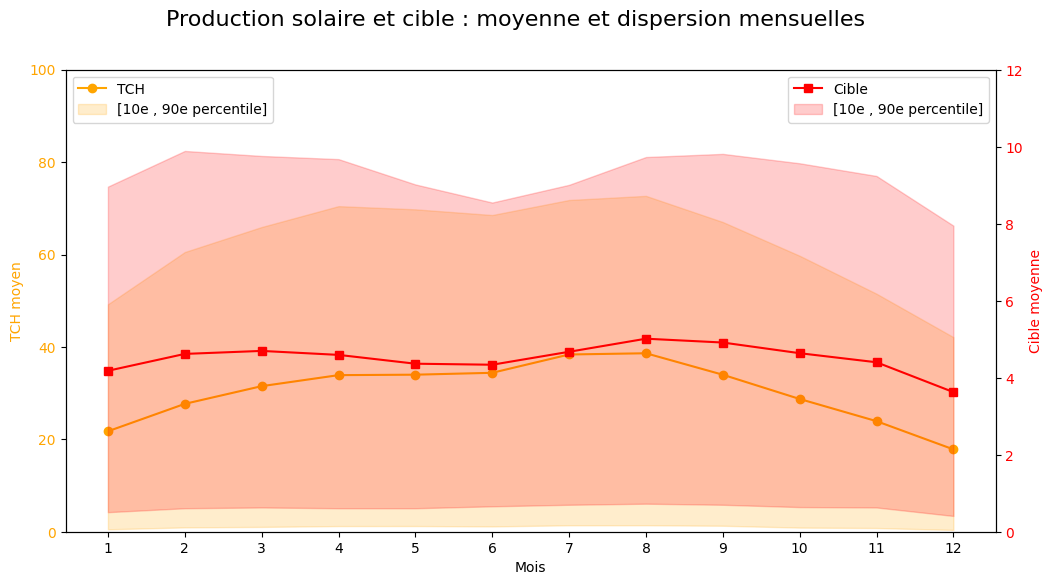

In [14]:
mois = monthly_stats.index
mean_tch = monthly_stats['tch_solaire']['mean']
mean_target = monthly_stats['target']['mean']

# Calcul des percentiles
p10_tch = monthly_stats['p10'] = df_day.groupby('month')['tch_solaire'].quantile(0.10)
p90_tch = monthly_stats['p90'] = df_day.groupby('month')['tch_solaire'].quantile(0.90)
p10_target = monthly_stats['p10'] = df_day.groupby('month')['target'].quantile(0.10)
p90_target = monthly_stats['p90'] = df_day.groupby('month')['target'].quantile(0.90)

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Tracer mean et std sur le même axe
ax1.plot(mois, mean_tch, marker='o', color='orange', label='TCH')
ax1.fill_between(mois, p10_tch, p90_tch, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Mois')
ax1.set_ylabel('TCH moyen', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(mois)
ax1.set_ylim(0, 100)

# Tracer CV sur un axe secondaire
ax2 = ax1.twinx()
ax2.plot(mois, mean_target, marker='s', color='red', label='Cible')
ax2.fill_between(mois, p10_target, p90_target, color='red', alpha=0.2, label='[10e , 90e percentile]')
ax2.set_ylabel('Cible moyenne', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 12)

# Titres et légendes
fig.suptitle('Production solaire et cible : moyenne et dispersion mensuelles', fontsize=16)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque mois :  
- la **moyenne du TCH** (courbe orange) ;  
- la **zone orange claire** représentant la **dispersion absolue** du TCH autour de la moyenne (écart-type) ;  
- la **variable cible** (courbe rouge sur l'axe secondaire);
- la **zone rouge claire** représentant la **dispersion absolue** autour de la moyenne (écart-type) de la variable cible ;


**Observations**

1. **Production solaire**
    - La bande est **plus large entre avril et août**, indiquant un **écart-type absolu élevé**, lié à des niveaux de production plus importants.
    - Elle est **plus étroite en hiver et en automne (d'octobre à février)**, lorsque la production moyenne est plus faible en valeur absolue.


2. **Variabilité absolue de la production solaire**
    - La **cible est plus faible et plus stable** en **mai et juin** ainsi qu'en **décembre et en janvier** ;
    - La **cible est légèrement plus élevée en fin d'hiver et en fin d'été**.


**Conclusion**
- En automne et en hiver, la production est **plus régulière relativement à son niveau moyen**.
- La variable cible permet de **comparer les mois entre eux**, indépendamment des différences de niveau moyen de production, et d'identifier les périodes **les plus stables et les plus instables**.


# V - Lien entre TCH solaire et les autres variables explicative

## A - Lien entre TCH et GHI régional

**GHI (Global Horizontal Irradiance)** désigne la quantité totale de rayonnement solaire reçue par une surface horizontale, incluant la composante directe et la composante diffuse.

Une fois `GHI_region` construite, l'objectif est d'analyser la sensibilité du TCH aux variations de l'irradiance globale régionale.  

On étudie comment le TCH évolue en fonction des hausses ou baisses du GHI afin de mettre en évidence une relation entre l'ensoleillement régional et le comportement du TCH.

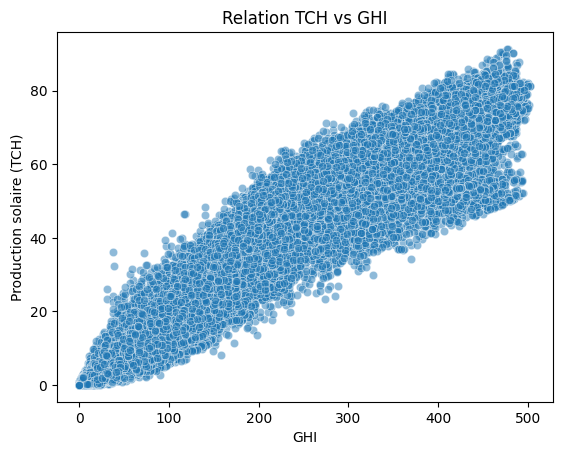

In [15]:
sns.scatterplot(x='region_ghi', y='tch_solaire', data=df_day, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Production solaire (TCH)')
plt.title('Relation TCH vs GHI')
plt.show()


Afin d'évaluer l'existence et l'intensité d'un lien statistique entre le GHI régional et le TCH, on calcule deus coefficients de corrélation (corrélation de **Pearson** et corrélation de **Spearman**) ainsi que leurs p-values associées, permettant d'apprécier la significativité de la relation observée.

In [16]:
corr_p, p_value_p = pearsonr(df_day['region_ghi'], df_day['tch_solaire'])
corr_s, p_value_s = spearmanr(df_day['region_ghi'], df_day['tch_solaire'])
print(f"Corrélation Pearson : {corr_p}")
print(f"P-value : {p_value_p}")
print(f"Corrélation Spearman : {corr_s}")
print(f"P-value : {p_value_s}")


Corrélation Pearson : 0.9596794656493629
P-value : 0.0
Corrélation Spearman : 0.971020771819272
P-value : 0.0


Les résultats montrent une **corrélation très forte et positive** entre le GHI régional et le TCH.  
Les coefficients, proches de 1, indiquent que le TCH augmente fortement lorsque le GHI régional augmente.  
Les p-values nulles confirment que cette relation est **hautement significative statistiquement**.


### 1 - Statistiques descriptives en fonction des niveaux d'irradiance

Dans cette étape, la production TCH est étudiée en fonction de classes de GHI définies par intervalles réguliers. Pour chaque bin d'irradiance, des statistiques descriptives sont calculées, notamment la moyenne, l'écart-type, les percentiles P10 et P90, ainsi que la variabilité.

Cette approche permet comme avant de caractériser la relation entre l'intensité de l'irradiance et la production solaire selon trois dimensions complémentaires : le niveau moyen de production, la dispersion absolue autour de cette moyenne et la variabilité relative au sein de chaque régime d'irradiance. 


/tmp/ipykernel_9900/2953940894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['ghi_bin'] = pd.cut(df_day['region_ghi'], bins)
/tmp/ipykernel_9900/2953940894.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_stats = df_day.groupby('ghi_bin')[['tch_solaire', 'target']].describe()
/tmp/ipykernel_9900/2953940894.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

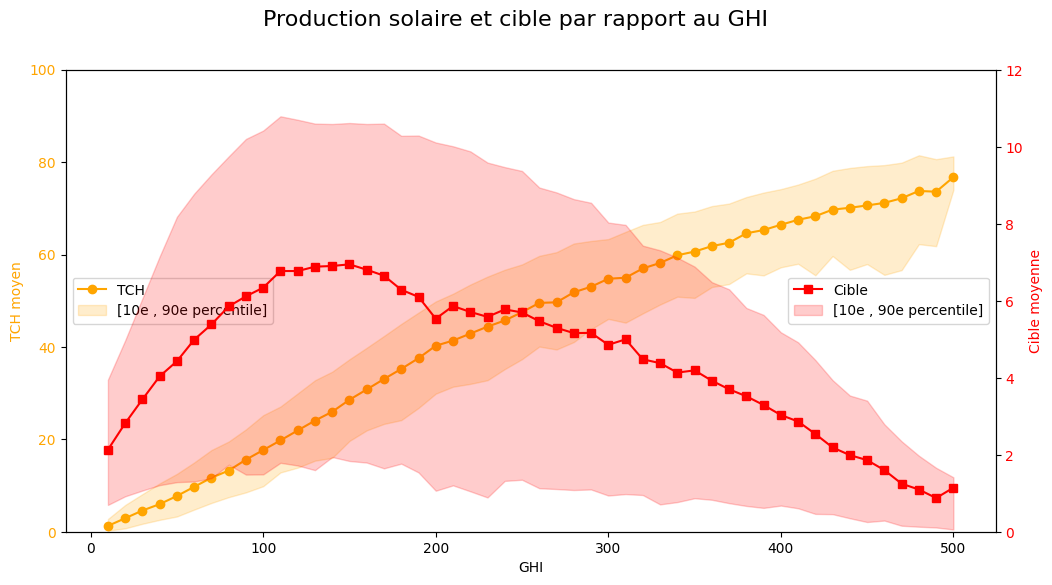

In [17]:
# Définir les bins
bins = range(5, int(df_day['region_ghi'].max()) + 50, 10)
df_day['ghi_bin'] = pd.cut(df_day['region_ghi'], bins)

# Stats par bin
ghi_stats = df_day.groupby('ghi_bin')[['tch_solaire', 'target']].describe()

# Percentiles P10 et P90
ghi_stats['p10_tch'] = df_day.groupby('ghi_bin')['tch_solaire'].quantile(0.10)
ghi_stats['p90_tch'] = df_day.groupby('ghi_bin')['tch_solaire'].quantile(0.90)
ghi_stats['p10_target'] = df_day.groupby('ghi_bin')['target'].quantile(0.10)
ghi_stats['p90_target'] = df_day.groupby('ghi_bin')['target'].quantile(0.90)

# Convertir l'IntervalIndex en valeur numérique (milieu du bin)
ghi_stats['GHI_mid'] = ghi_stats.index.map(lambda x: x.mid)

# Variables pour le tracé
ghi = ghi_stats['GHI_mid']
mean_tch = ghi_stats['tch_solaire']['mean']
mean_target = ghi_stats['target']['mean']
p10_tch = ghi_stats['p10_tch']
p90_tch = ghi_stats['p90_tch']
p10_target = ghi_stats['p10_target']
p90_target = ghi_stats['p90_target']

# Tracé
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande P10-P90
ax1.plot(ghi, mean_tch, marker='o', color='orange', label='TCH')
ax1.fill_between(ghi, p10_tch, p90_tch, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('GHI')
ax1.set_ylabel('TCH moyen', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_ylim(0, 100)

# Cible sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(ghi, mean_target, marker='s', color='red', label='Cible')
ax2.fill_between(ghi, p10_target, p90_target, color='red', alpha=0.2, label='[10e , 90e percentile]')
ax2.set_ylabel('Cible moyenne', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 12)

# Titres et légendes
fig.suptitle('Production solaire et cible par rapport au GHI', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


### 2 - **Interprétation du graphique**

Le graphique présente, pour chaque classe de GHI, la moyenne de TCH, l'intervalle P10–P90 et la variable cible.

### 3 - **Principales observations**

1. La moyenne de TCH augmente régulièrement avec le GHI, ce qui traduit une relation cohérente entre irradiance et production.

2. La dispersion absolue (P10–P90) s'élargit avec le GHI. Aux faibles GHI, les valeurs restent concentrées à bas niveau. Aux GHI moyens et élevés, les valeurs sont plus étalées en valeur absolue autour de la moyenne.

3. La variabilité de la production solaire est faible aux faibles GHI (peu de production au lever et coucher du jour), atteint un maximum vers GHI = 150, ce indique une variabilité relative importante pour une production moyenne faible. Au delà de cette valeur du GHI, la variabilité de la production solaire diminue progressivement lorsque le GHI augmente : la production devient alors plus stable proportionnellement à sa moyenne.

### 4 - **Conclusion**

La production est faible et instable en proportion aux faibles irradiances, alors qu'elle devient élevée et relativement plus stable aux irradiances élevées. La variabilité absolue augmente avec la production, tandis que la variabilité relative diminue avec le GHI.


## B - Lien entre TCH et angles solaires

In [18]:
zenith_deg = 90.0 - df_day["region_altitude"]
zenith_rad = np.deg2rad(zenith_deg)
df_day["cos_zenith_region"] = np.cos(zenith_rad)

# Mettre 0 la nuit si altitude <= 0
df_day.loc[df_day["region_altitude"] <= 0, "cos_zenith_region"] = 0

/tmp/ipykernel_9900/171070975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_zenith_region"] = np.cos(zenith_rad)


### 1 - **Interprétation :**

- `cos_zenith_region` proche de 1 → soleil très haut (midi, été) → TCH potentiel max
- `cos_zenith_region` proche de 0 → soleil rasant / nuit → très peu de production possible
  
### 2 - **Calcul de l'angle d'incidence solaire sur les panneaux**

`cos_incidence` mesure l'angle entre la surface du panneau et la direction du soleil.

Formule trigonométrique pour un panneau incliné et orienté :

$$
\cos(\theta) = \sin(\alpha) \cdot \cos(\beta) + \cos(\alpha) \cdot \sin(\beta) \cdot \cos(\gamma_s - \gamma_p)
$$

- **$\alpha$** = altitude du soleil  
- **$\beta$** = inclinaison des panneaux par rapport à l'horizontale, en degrés  
- **$\gamma_s$** = azimut du soleil  
- **$\gamma_p$** = orientation (azimut) des panneaux, en degrés.  

**Interprétation :**

- `cos_incidence proche 1` → soleil perpendiculaire au panneau → production maximale  
- `cos_incidence proche 0` → soleil très oblique → peu de production  
- `cos_incidence < 0` → soleil derrière le panneau → pas de production


In [19]:
# Hypothèses
beta_deg = 30.0        # inclinaison des panneaux
gamma_p_deg = 180.0    # azimuth panneaux (Sud)

alpha_rad = np.deg2rad(df_day["region_altitude"])
gamma_s_rad = np.deg2rad(df_day["region_azimuth"])
beta_rad = np.deg2rad(beta_deg)
gamma_p_rad = np.deg2rad(gamma_p_deg)

df_day["cos_incidence_region"] = (
    np.sin(alpha_rad) * np.cos(beta_rad)
    + np.cos(alpha_rad) * np.sin(beta_rad) * np.cos(gamma_s_rad - gamma_p_rad)
)

# On met 0 la nuit ou quand le soleil est derrière les panneaux
df_day.loc[(df_day["region_altitude"] <= 0) | (df_day["cos_incidence_region"] < 0), "cos_incidence_region"] = 0


/tmp/ipykernel_9900/1103466848.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_incidence_region"] = (


### 3 - **Corrélation entre angles solaires et production TCH**

In [20]:
print("Corr cos_zenith/TCH :", pearsonr(df_day["cos_zenith_region"], df_day["tch_solaire"]))
print("Corr cos_incidence/TCH :", pearsonr(df_day["cos_incidence_region"], df_day["tch_solaire"]))
print("Corr cos_zenith_region/cos_incidence_region :", pearsonr(df_day["cos_zenith_region"], df_day["cos_incidence_region"]))


Corr cos_zenith/TCH : PearsonRResult(statistic=0.8654194973994171, pvalue=0.0)
Corr cos_incidence/TCH : PearsonRResult(statistic=0.8224783748691198, pvalue=0.0)
Corr cos_zenith_region/cos_incidence_region : PearsonRResult(statistic=0.8675663311958798, pvalue=0.0)


### 4 - **Analyse des corrélations avec le TCH**

Les corrélations entre le TCH et les variables géométriques `cos_zenith_region` et `cos_incidence_region` sont très élevées. Cela confirme que la **position du soleil** dans le ciel (géométrie solaire) explique une part importante de la variabilité du TCH.

On observe que :  
- `cos_zenith_region` corrèle légèrement mieux avec le TCH que `cos_incidence_region`.  
- `cos_incidence_region` repose sur une **hypothèse d'orientation** moyenne des panneaux (inclinaison et azimuth).  
  Si cette hypothèse ne reflète pas fidèlement la réalité du parc photovoltaïque (orientations variées, installations Est/Ouest, toitures, etc.), cette variable devient moins représentative.  
- À l'inverse, `cos_zenith_region` dépend uniquement de la **hauteur du soleil** et reste valable quelles que soient les orientations réelles des installations.  

Par ailleurs, les deux variables `cos_zenith_region` et `cos_incidence_region` sont fortement corrélées entre elles, ce qui les rend presque **redondantes** d'un point de vue statistique.


**Conclusion:**
`cos_incidence_region` n'apporte pas d'information supplémentaire significative par rapport à cos_zenith_region.
Dans la suite de l'analyse, nous conservons donc **`cos_zenith_region` comme feature principale**.


## C - Lien entre TCH et nébulosité régionale

L'analyse précédente a montré comment la production TCH évolue en fonction du GHI, avec une augmentation de la moyenne et une diminution progressive de la variabilité relative lorsque l'irradiance augmente. Cependant, le GHI ne reflète pas uniquement l'intensité solaire ; il est également influencé par la présence et la dynamique des nuages.

Pour mieux comprendre le rôle spécifique de la couverture nuageuse dans la variabilité de la production, nous regroupons maintenant les données selon des **catégories de nébulosité** (clair, partiellement clair, nuageux, très nuageux) et observons la distribution de TCH au sein de chaque catégorie à l'aide d'un boxplot. Cette étape permet de distinguer les effets liés à la radiation solaire de ceux associés aux conditions atmosphériques et d'identifier plus précisément comment les nuages impactent la stabilité et l'amplitude de la production solaire.


/tmp/ipykernel_9900/1937128004.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category'] = pd.cut(df_day['region_nebulosite'], bins=bins, labels=labels, include_lowest=True)


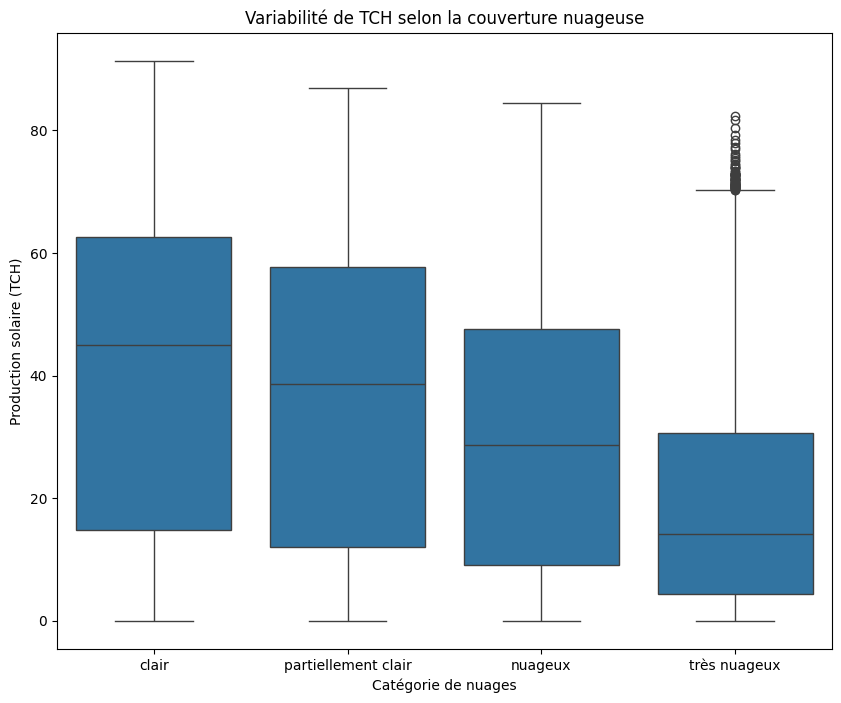

In [21]:
bins = [0, 20, 50, 80, 100]
labels = ['clair', 'partiellement clair', 'nuageux', 'très nuageux']
df_day['cloud_category'] = pd.cut(df_day['region_nebulosite'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category', y='tch_solaire', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()


Le boxplot montre la distribution de la production solaire (TCH) pour différentes catégories de couverture nuageuse. La médiane, la dispersion et les valeurs extrêmes permettent d'identifier l'impact des nuages sur le niveau et la variabilité de la production.

- **Clair**: Production moyenne élevée avec des valeurs maximales importantes. La dispersion en valeur absolue est large, ce qui correspond à un régime de production intense mais étendu.

- **Partiellement clair**: Production intermédiaire, avec une variabilité marquée liée à l'alternance entre ensoleillement et passages nuageux.

- **Nuageux**: Production plus faible et plus homogène, avec une dispersion resserrée autour de valeurs modérées.

- **Très nuageux**: Production basse en moyenne. La majorité des valeurs se situe dans la zone basse, avec quelques pics ponctuels associés à des éclaircies.


### 1 - Passage d'une nébulosité observée à une nébulosité radiative (CSI)

La classification précédente repose sur la **nébulosité régionale exprimée en pourcentage**, qui décrit l'état du ciel d'un point de vue météorologique. Toutefois, cette variable ne quantifie pas directement l'**atténuation effective du rayonnement solaire** reçue au sol.

Afin de mieux relier les conditions atmosphériques à la production photovoltaïque, nous introduisons l'**indice de ciel clair (Clear Sky Index – CSI)**, défini comme le rapport entre l'irradiance globale mesurée et l'irradiance théorique en conditions de ciel clair :

$$
\mathrm{CSI} = \frac{\mathrm{GHI}}{\mathrm{GHI}_{\text{clear-sky}}}
$$

Cette approche permet de regrouper les données selon des **catégories de nébulosité radiative**, basées sur la réduction réelle du rayonnement solaire. La cellule suivante analyse ainsi la variabilité de la production solaire (TCH) en fonction de ces classes de CSI à l'aide d'un boxplot.


/tmp/ipykernel_9900/3054169327.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["CSI"] = df_day["region_ghi"] / df_day["region_clear_sky_ghi"]
/tmp/ipykernel_9900/3054169327.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)


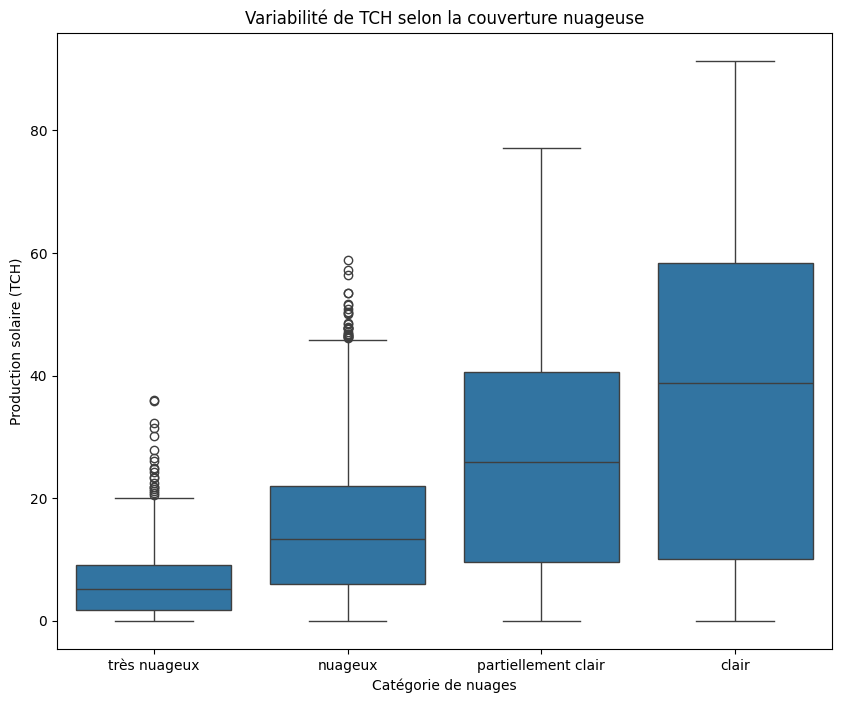

In [22]:
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['très nuageux', 'nuageux', 'partiellement clair', 'clair']
df_day["CSI"] = df_day["region_ghi"] / df_day["region_clear_sky_ghi"]
df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category_CSI', y='tch_solaire', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()

**Comparaison entre nébulosité observée et nébulosité radiative**

L'analyse basée sur l'indice de ciel clair (CSI) met en évidence un **comportement globalement identique** à celui observé précédemment avec la nébulosité régionale exprimée en pourcentage.

Dans les deux approches, la production solaire (TCH) :
- diminue progressivement lorsque la couverture nuageuse augmente,
- devient plus faible et plus homogène sous des conditions fortement nuageuses.

Cette cohérence entre les deux classifications confirme que la **variabilité de TCH est principalement gouvernée par l'atténuation radiative induite par les nuages**, et non uniquement par leur présence apparente. L'utilisation du CSI permet toutefois une interprétation plus directement liée aux mécanismes physiques de réduction de l'irradiance, renforçant ainsi la robustesse de l'analyse.


### 2 - Lecture par *régimes de ciel* : classes de **GHI**

Le **GHI** est une **variable intégratrice** qui “voit” à la fois :
- la géométrie solaire (cycle journalier / saison),
- et surtout l'**atténuation nuageuse**, qui crée la **variabilité** (jours clairs vs jours perturbés).

On segmente donc les journées en **classes de GHI** (faible → fort) afin de comparer, *à régime comparable*, la dispersion de la production (**TCH**) et des composantes radiatives (BNI/BHI/DHI).

**Étape 1 — Définir les bornes de GHI**

- *faible GHI* : jours très nuageux / atténuation forte,
- *GHI intermédiaire* : ciel variable,
- *fort GHI* : jours clairs (variabilité faible).


**Étape 2 — Comparer la dispersion (variabilité) par régime**

Pour chaque classe de GHI, on regarde comment la production et/ou les composantes radiatives se distribuent.
Visuellement, si le **GHI** est bien le “moteur” de variabilité, on doit observer :
- une **dispersion plus large** quand le GHI est faible/intermédiaire,
- une **dispersion resserrée** quand le GHI est élevé (jours clairs).

/tmp/ipykernel_9900/3799614164.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['GHI_bin2'] = pd.cut(
/tmp/ipykernel_9900/3799614164.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


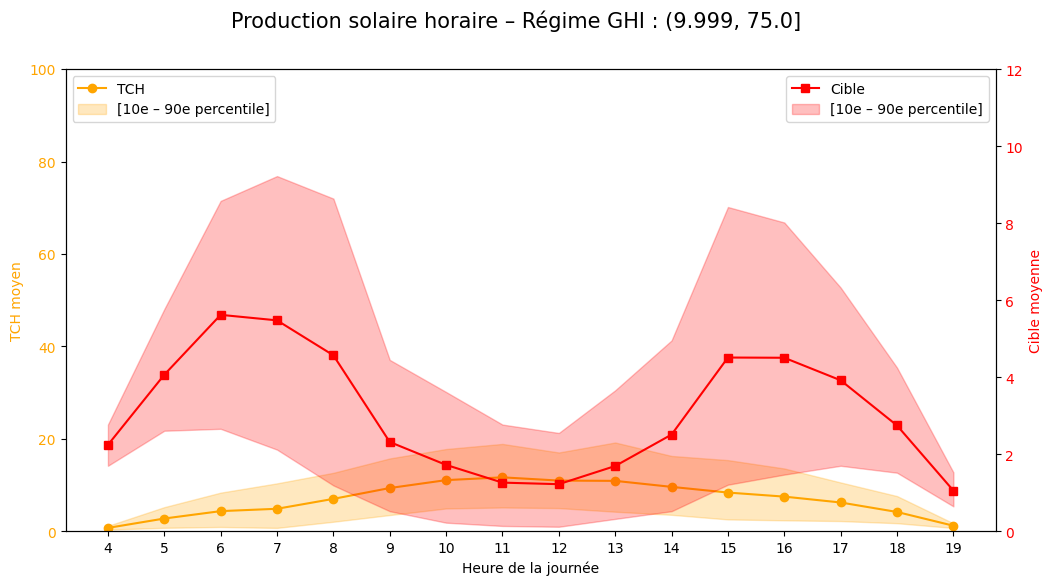

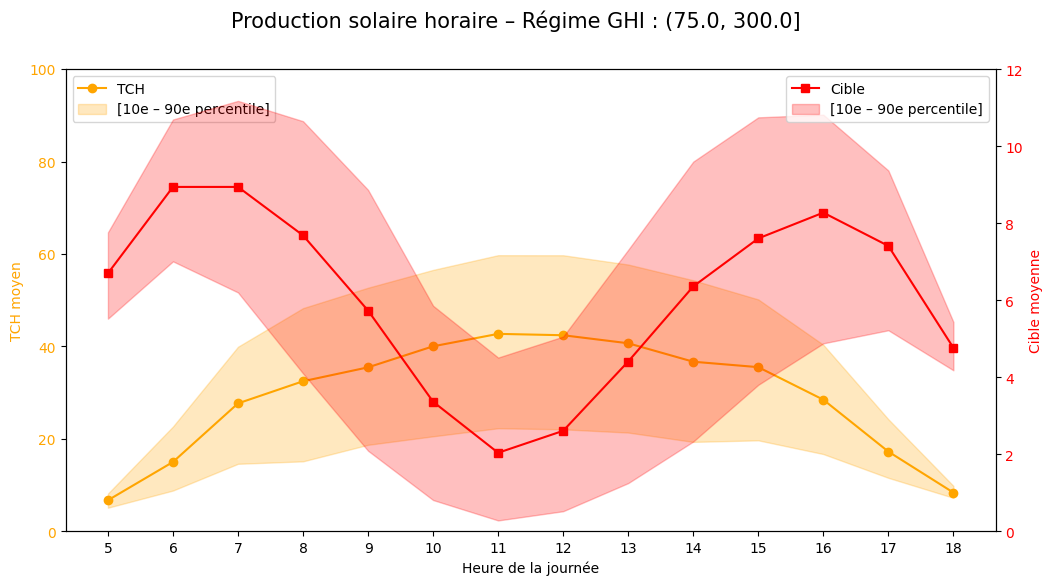

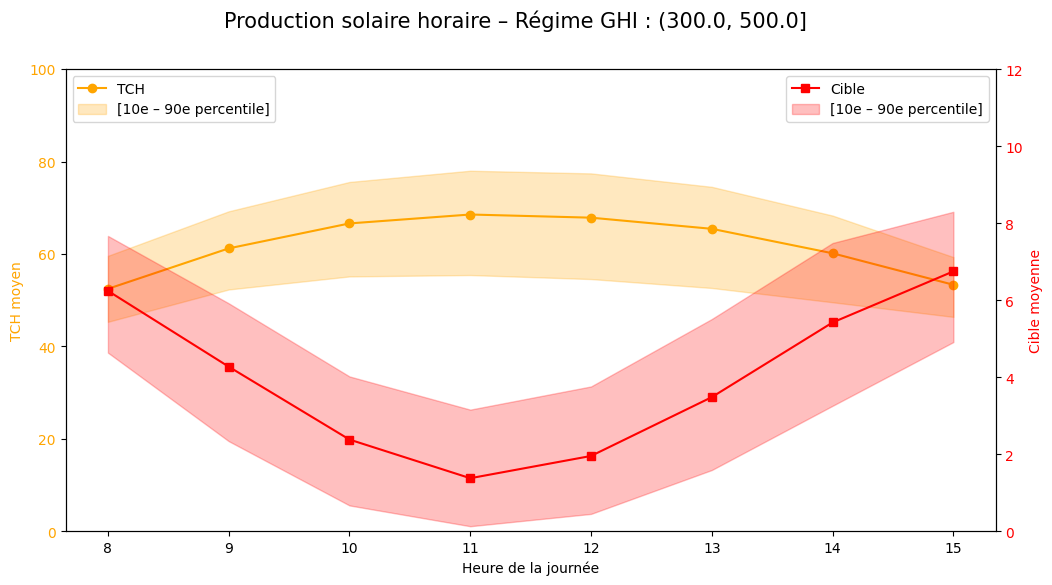

In [23]:
bins = [10, 75, 300, 500]

df_day['GHI_bin2'] = pd.cut(
    df_day['region_ghi'],
    bins=bins,
    include_lowest=True
)


for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    hour_stats = df_bin.groupby('hour')[['tch_solaire', 'target']].describe()

    # Percentiles
    hour_stats['p10_tch'] = df_bin.groupby('hour')['tch_solaire'].quantile(0.10)
    hour_stats['p90_tch'] = df_bin.groupby('hour')['tch_solaire'].quantile(0.90)
    hour_stats['p10_target'] = df_bin.groupby('hour')['target'].quantile(0.10)
    hour_stats['p90_target'] = df_bin.groupby('hour')['target'].quantile(0.90)
    # display(hour_stats)
    
    heures = hour_stats.index
    mean_tch = hour_stats['tch_solaire']['mean']
    mean_target = hour_stats['target']['mean']
    p10_tch = hour_stats['p10_tch']
    p90_tch = hour_stats['p90_tch']
    p10_target = hour_stats['p10_target']
    p90_target = hour_stats['p90_target']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(heures, mean_tch, marker='o', color='orange', label='TCH')
    ax1.fill_between(heures, p10_tch, p90_tch, color='orange', alpha=0.25,label='[10e – 90e percentile]')
    ax1.set_xlabel('Heure de la journée')
    ax1.set_ylabel('TCH moyen', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(heures)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(heures, mean_target, marker='s', color='red', label='Cible')
    ax2.fill_between(heures, p10_target, p90_target, color='red', alpha=0.25,label='[10e – 90e percentile]')
    ax2.set_ylabel('Cible moyenne', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 12)

    # Titre et légendes
    fig.suptitle(
        f'Production solaire horaire – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_9900/974203246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


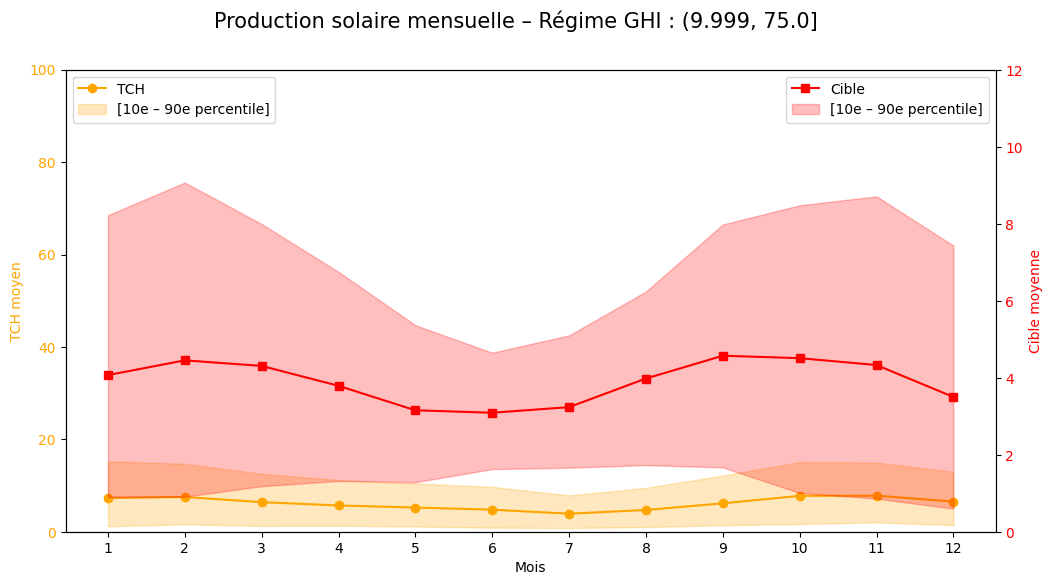

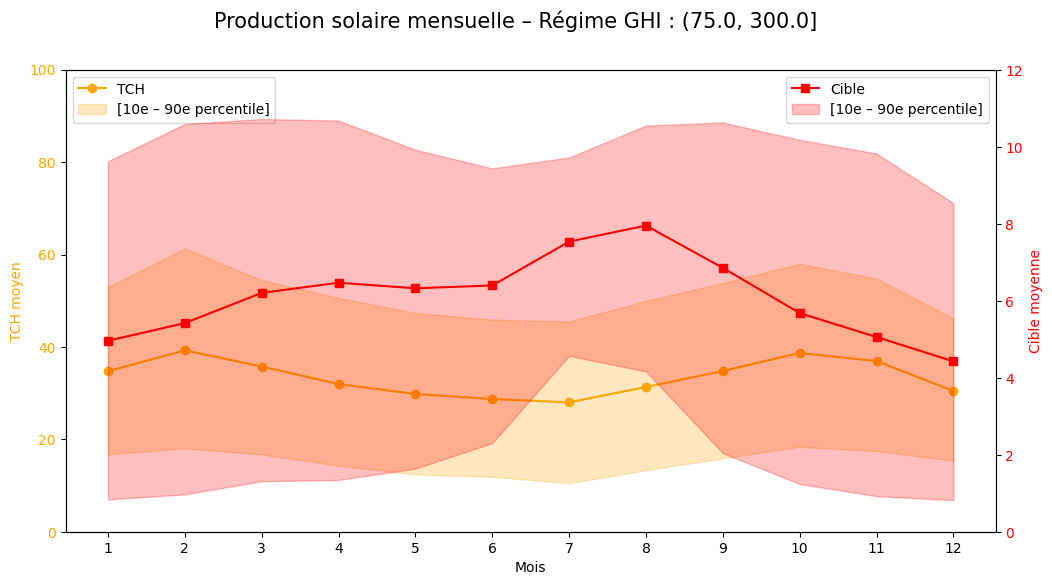

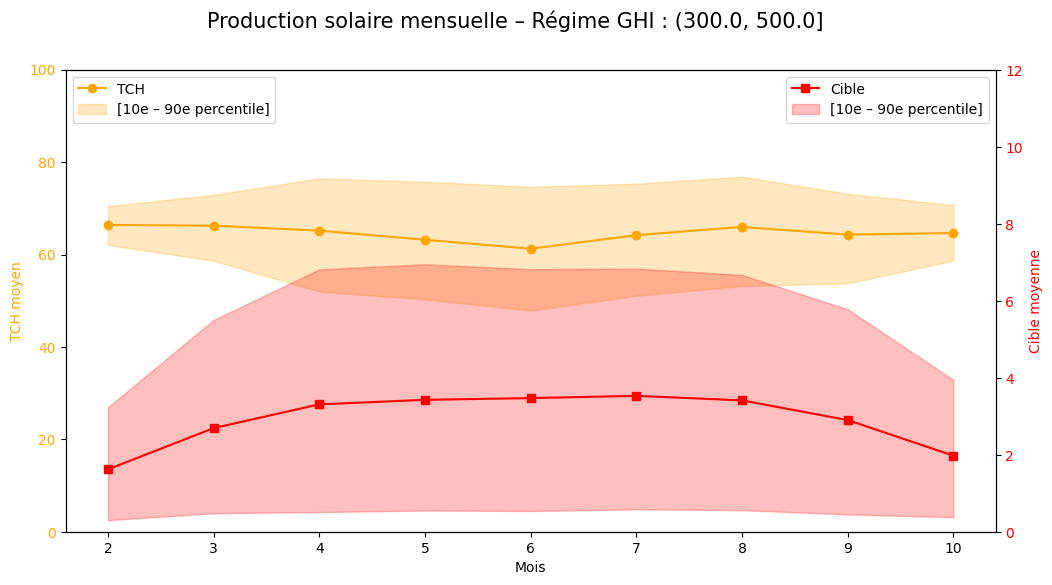

In [24]:
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    month_stats = df_bin.groupby('month')[['tch_solaire', 'target']].describe()

    # Percentiles
    month_stats['p10_tch'] = df_bin.groupby('month')['tch_solaire'].quantile(0.10)
    month_stats['p90_tch'] = df_bin.groupby('month')['tch_solaire'].quantile(0.90)
    month_stats['p10_target'] = df_bin.groupby('month')['target'].quantile(0.10)
    month_stats['p90_target'] = df_bin.groupby('month')['target'].quantile(0.90)

    mois = month_stats.index
    mean_tch = month_stats['tch_solaire']['mean']
    mean_target = month_stats['target']['mean']
    p10_tch = month_stats['p10_tch']
    p90_tch = month_stats['p90_tch']
    p10_target = month_stats['p10_target']
    p90_target = month_stats['p90_target']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(mois, mean_tch, marker='o', color='orange', label='TCH')
    ax1.fill_between(mois, p10_tch, p90_tch, color='orange', alpha=0.25,label='[10e – 90e percentile]')
    ax1.set_xlabel('Mois')
    ax1.set_ylabel('TCH moyen', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(mois)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(mois, mean_target, marker='s', color='red', label='Cible')
    ax2.fill_between(mois, p10_target, p90_target, color='red', alpha=0.25,label='[10e – 90e percentile]')
    ax2.set_ylabel('Cible moyenne', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 12)

    # Titre et légendes
    fig.suptitle(
        f'Production solaire mensuelle – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_9900/1669933010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['doy'] = df_day.index.dayofyear
/tmp/ipykernel_9900/1669933010.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


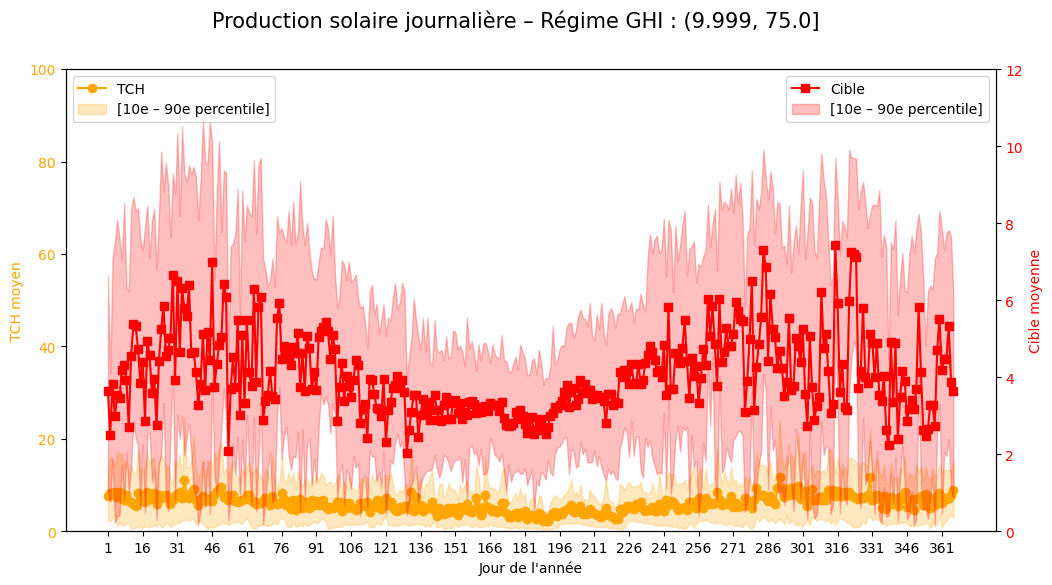

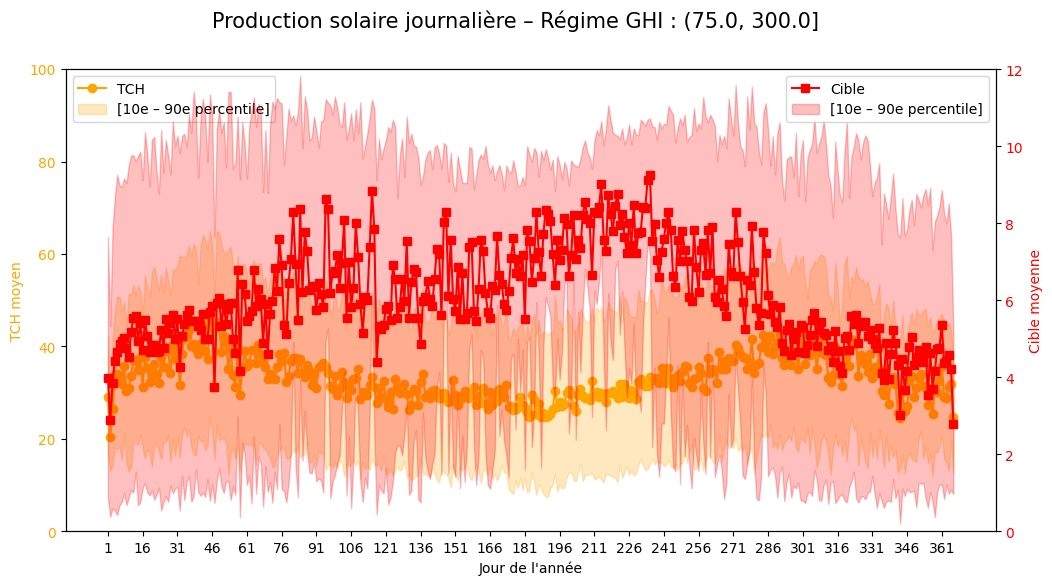

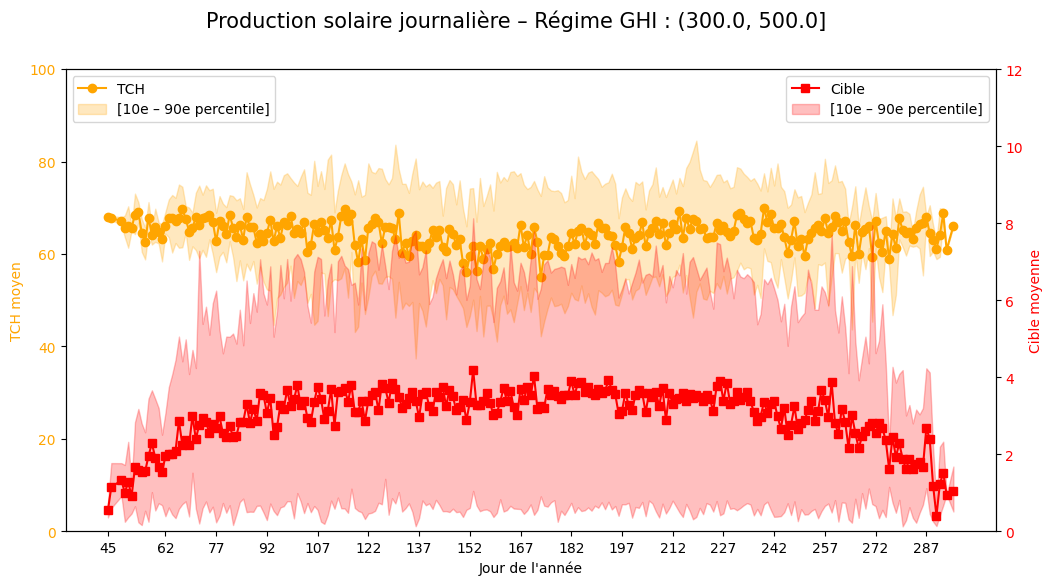

In [25]:
df_day['doy'] = df_day.index.dayofyear
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    jour_stats = df_bin.groupby('doy')[['tch_solaire', 'target']].describe()

    # Percentiles
    jour_stats['p10_tch'] = df_bin.groupby('doy')['tch_solaire'].quantile(0.10)
    jour_stats['p90_tch'] = df_bin.groupby('doy')['tch_solaire'].quantile(0.90)
    jour_stats['p10_target'] = df_bin.groupby('doy')['target'].quantile(0.10)
    jour_stats['p90_target'] = df_bin.groupby('doy')['target'].quantile(0.90)

    jours = jour_stats.index
    mean_tch = jour_stats['tch_solaire']['mean']
    mean_target = jour_stats['target']['mean']
    p10_tch = jour_stats['p10_tch']
    p90_tch = jour_stats['p90_tch']
    p10_target = jour_stats['p10_target']
    p90_target = jour_stats['p90_target']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(jours, mean_tch, marker='o', color='orange', label='TCH')
    ax1.fill_between(jours, p10_tch, p90_tch, color='orange', alpha=0.25,label='[10e – 90e percentile]')
    ax1.set_xlabel("Jour de l'année")
    ax1.set_ylabel('TCH moyen', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(jours[::15])

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(jours, mean_target, marker='s', color='red', label='Cible')
    ax2.fill_between(jours, p10_target, p90_target, color='red', alpha=0.25,label='[10e – 90e percentile]')
    ax2.set_ylabel('Cible moyenne', color='red')
    ax2.set_ylim(0, 12)
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire journalière – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


## D - Conclusion : pourquoi le **GHI** porte l'essentiel de la variabilité

Les figures par **régime de GHI** montrent une lecture très claire :

- Quand le **GHI est faible** (journées nuageuses / diffus), la production **TCH** devient **plus instable** : la bande *P10–P90* s'élargit et le **CV** (variabilité relative) augmente.
- Quand le **GHI est élevé** (journées dégagées), la production est **plus régulière** : la dispersion se resserre et le **CV** diminue.

Autrement dit, **le GHI est la variable qui “déclenche” la variabilité** observée dans la production : il capte à la fois l'intensité du rayonnement reçu et, indirectement, l'état du ciel (clair vs couvert) qui gouverne la fluctuation.